In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import math


In [1]:
pip install networkx matplotlib numpy

# Question 1


## Question 1.1

In [ ]:
# filename = "facebook_combined.txt"
url = "https://raw.githubusercontent.com/anwxwna/232E_sp26/refs/heads/main/facebook_combined.txt"
filename = "./facebook_combined.txt"
urllib.request.urlretrieve(url, filename)

G = nx.read_edgelist(filename, create_using=nx.Graph(), nodetype=int)

# Step 3: Basic info
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {num_edges}")

Number of nodes: 4039
Number of edges: 88234


## Question 1.2

In [ ]:
is_connected = nx.is_connected(G)
print(f"Is the network connected? {is_connected}")

if not is_connected:
    gcc = max(nx.connected_components(G), key=len)
    G_gcc = G.subgraph(gcc).copy()
else:
    G_gcc = G

print(f"Size of GCC - Nodes: {G_gcc.number_of_nodes()}, Edges: {G_gcc.number_of_edges()}")

Is the network connected? True
Size of GCC - Nodes: 4039, Edges: 88234


# Question 2
Find the diameter of the network. If the network is not connected, then find the
diameter of the GCC.

In [ ]:
diameter = nx.diameter(G_gcc)
print(f"Diameter of the network (or GCC): {diameter}")

Diameter of the network (or GCC): 8


# Question 3
Plot the degree distribution of the facebook network and report the average
degree.

Average degree: 43.69


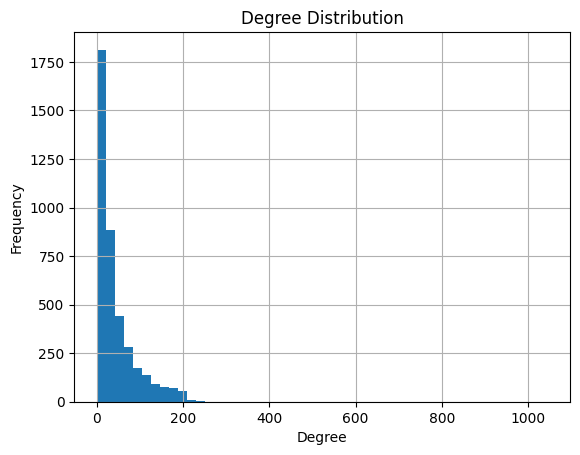

In [ ]:
degrees = [d for n, d in G.degree()]
avg_degree = np.mean(degrees)
print(f"Average degree: {avg_degree:.2f}")

# Plot degree distribution
plt.figure()
plt.hist(degrees, bins=50)
plt.title("Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()

# QUESTION 4:
Plot the degree distribution of Question 3 in a log-log scale. Try to fit a line to
the plot and estimate the slope of the line.

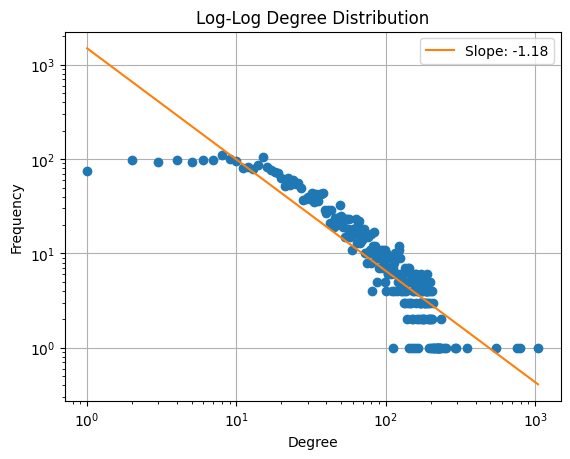

Estimated slope of the log-log plot: -1.18


In [ ]:
degree_counts = np.bincount(degrees)
degree_values = np.nonzero(degree_counts)[0]
counts = degree_counts[degree_values]

plt.figure()
plt.loglog(degree_values, counts, marker='o', linestyle='None')
plt.title("Log-Log Degree Distribution")
plt.xlabel("Degree")
plt.ylabel("Frequency")

# Fit line to log-log plot
log_degrees = np.log(degree_values)
log_counts = np.log(counts)
slope, intercept = np.polyfit(log_degrees, log_counts, 1)
plt.plot(degree_values, np.exp(intercept) * degree_values**slope, label=f"Slope: {slope:.2f}")
plt.legend()
plt.grid(True)
plt.show()

print(f"Estimated slope of the log-log plot: {slope:.2f}")

# QUESTION 5:
Create a personalized network of the user whose ID is 1. How many nodes and
edges does this personalized network have?

In [ ]:
target_node = 0  # user whose ID is 1
personalized_net = nx.ego_graph(G, target_node)  # ego_graph returns node + neighbors

pn_nodes = personalized_net.number_of_nodes()
pn_edges = personalized_net.number_of_edges()
print(f"Personalized Network Nodes: {pn_nodes}")
print(f"Personalized Network Edges: {pn_edges}")

Personalized Network Nodes: 348
Personalized Network Edges: 2866


# QUESTION 6:
What is the diameter of the personalized network? Please state a trivial upper
and lower bound for the diameter of the personalized network.

In [ ]:
pn_diameter = nx.diameter(personalized_net)
print(f"Diameter of the Personalized Network: {pn_diameter}")

Diameter of the Personalized Network: 2


In [ ]:
lower_bound = 1  # Minimum if everyone is directly connected
upper_bound = 2  # Max because all nodes are neighbors of center or each other
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")

Lower Bound: 1
Upper Bound: 2


# QUESTION 7:
In the context of the personalized network, what is the meaning of the diameter
of the personalized network to be equal to the upper bound you derived in Question 6. What is the
meaning of the diameter of the personalized network to be equal to the lower bound you derived in
Question 6 (assuming there are more than 3 nodes in the personalized network)?

In [ ]:
if pn_diameter == upper_bound:
    print("Diameter equals upper bound: Some neighbors are not directly connected to each other.")
elif pn_diameter == lower_bound:
    print("Diameter equals lower bound: All neighbors are directly connected to each other (clique).")
else:
    print("Diameter is between bounds: Intermediate connectivity among neighbors.")

Diameter equals upper bound: Some neighbors are not directly connected to each other.


Since the diameter of the personalized network is equal to the upper bound (2), it means that the users are not directly connected to one another, but must go through the central user to reach others. That means the the network is not fully connected like a clique ,but has more of a star like structure where most friends are connected through the user

# QUESTION 8:
How many core nodes are there in the Facebook network. What is the average degree of the core nodes?

In [ ]:
# Get degree of each node
node_degrees = dict(G.degree())

# Core nodes: nodes with degree > 200
core_nodes = [node for node, deg in node_degrees.items() if deg > 200]

# Number of core nodes
num_core_nodes = len(core_nodes)
print(f"Number of core nodes: {num_core_nodes}")

# Average degree of core nodes
avg_core_degree = np.mean([node_degrees[node] for node in core_nodes])
print(f"Average degree of core nodes: {avg_core_degree:.2f}")

Number of core nodes: 40
Average degree of core nodes: 279.38


# QUESTION 9:
For each of the above core node’s personalized network, find the community structure
using Fast-Greedy, Edge-Betweenness, and Infomap community detection algorithms. Compare
the modularity scores of the algorithms. For visualization purpose, display the community structure
of the core node’s personalized networks using colors. Nodes belonging to the same community
should have the same color and nodes belonging to different communities should have different
color. In this question, you should have 15 plots in total.

In [ ]:
import networkx as nx
import igraph as ig
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import random

# From assignment specification, core nodes are given as:
# core node = node ID - 1
core_nodes = [0, 107, 348, 483, 1086]

# Helper function to plot communities
def plot_communities(G_personal, membership, title):
    pos = nx.spring_layout(G_personal, seed=42)
    communities = {}
    for idx, cluster_id in enumerate(membership):
        communities.setdefault(cluster_id, []).append(idx)

    colors = list(mcolors.TABLEAU_COLORS.values()) + list(mcolors.CSS4_COLORS.values())
    random.shuffle(colors)

    plt.figure(figsize=(6, 6))
    for cluster_id, nodes in communities.items():
        node_list = [list(G_personal.nodes())[node_idx] for node_idx in nodes]
        nx.draw_networkx_nodes(G_personal, pos, nodelist=node_list, node_color=colors[cluster_id % len(colors)], label=f'Community {cluster_id}')
    nx.draw_networkx_edges(G_personal, pos, alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.legend()
    plt.show()

def fast_greedy(G_personal, core_node):
    G_ig = ig.Graph.TupleList(G_personal.edges(), directed=False)
    fg_clusters = G_ig.community_fastgreedy().as_clustering()
    modularity = G_ig.modularity(fg_clusters.membership)
    plot_communities(G_personal, fg_clusters.membership, f"Fast-Greedy (Core {core_node})")
    return modularity

def edge_betweenness(G_personal, core_node):
    G_ig = ig.Graph.TupleList(G_personal.edges(), directed=False)
    eb_clusters = G_ig.community_edge_betweenness().as_clustering()
    modularity = G_ig.modularity(eb_clusters.membership)
    plot_communities(G_personal, eb_clusters.membership, f"Edge-Betweenness (Core {core_node})")
    return modularity

def infomap(G_personal, core_node):
    G_ig = ig.Graph.TupleList(G_personal.edges(), directed=False)
    im_clusters = G_ig.community_infomap()
    modularity = G_ig.modularity(im_clusters.membership)
    plot_communities(G_personal, im_clusters.membership, f"Infomap (Core {core_node})")
    return modularity

=== Core node 0 ===


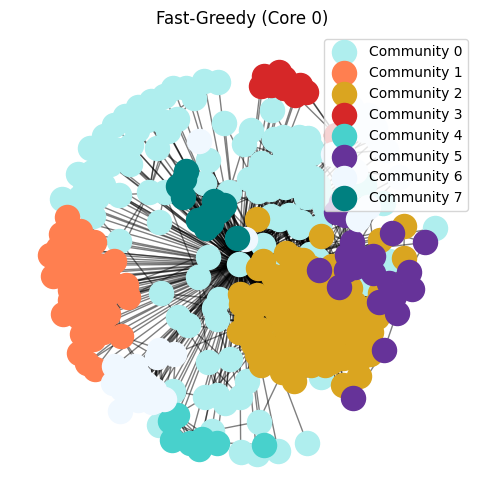

Fast-Greedy modularity: 0.4131


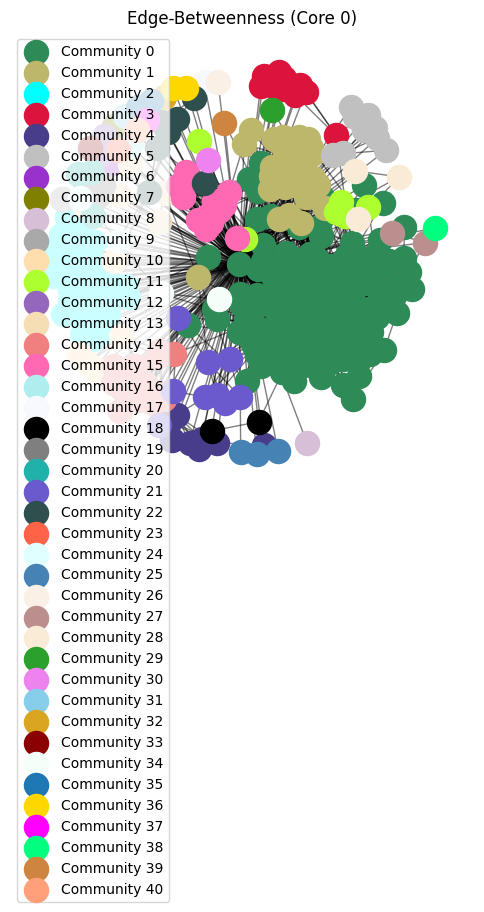

Edge-Betweenness modularity: 0.3533


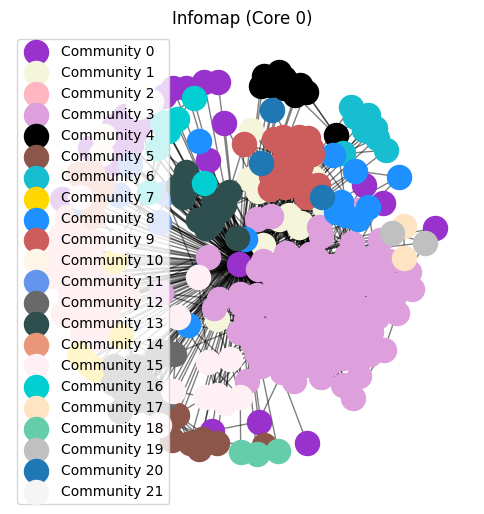

Infomap modularity: 0.3899
=== Core node 107 ===


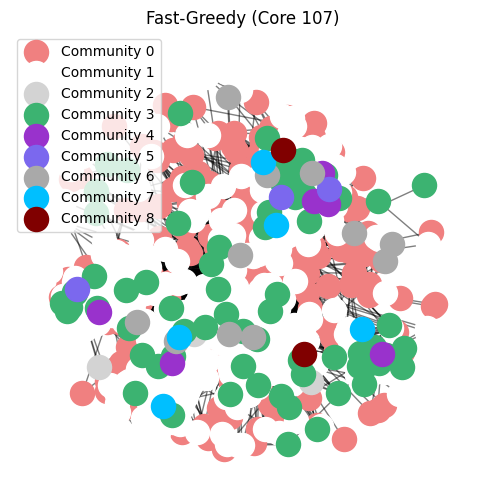

Fast-Greedy modularity: 0.4368


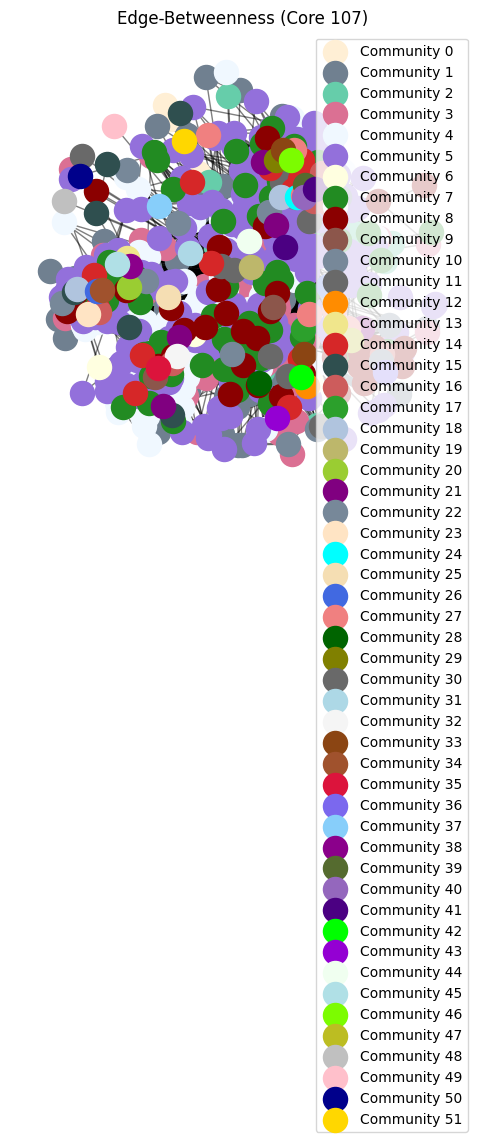

Edge-Betweenness modularity: 0.5068


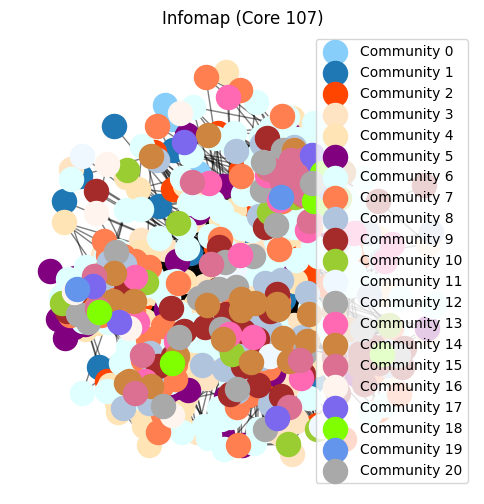

Infomap modularity: 0.5090
=== Core node 348 ===


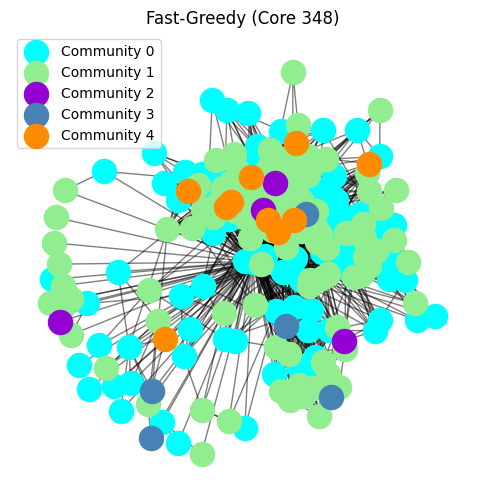

Fast-Greedy modularity: 0.2503


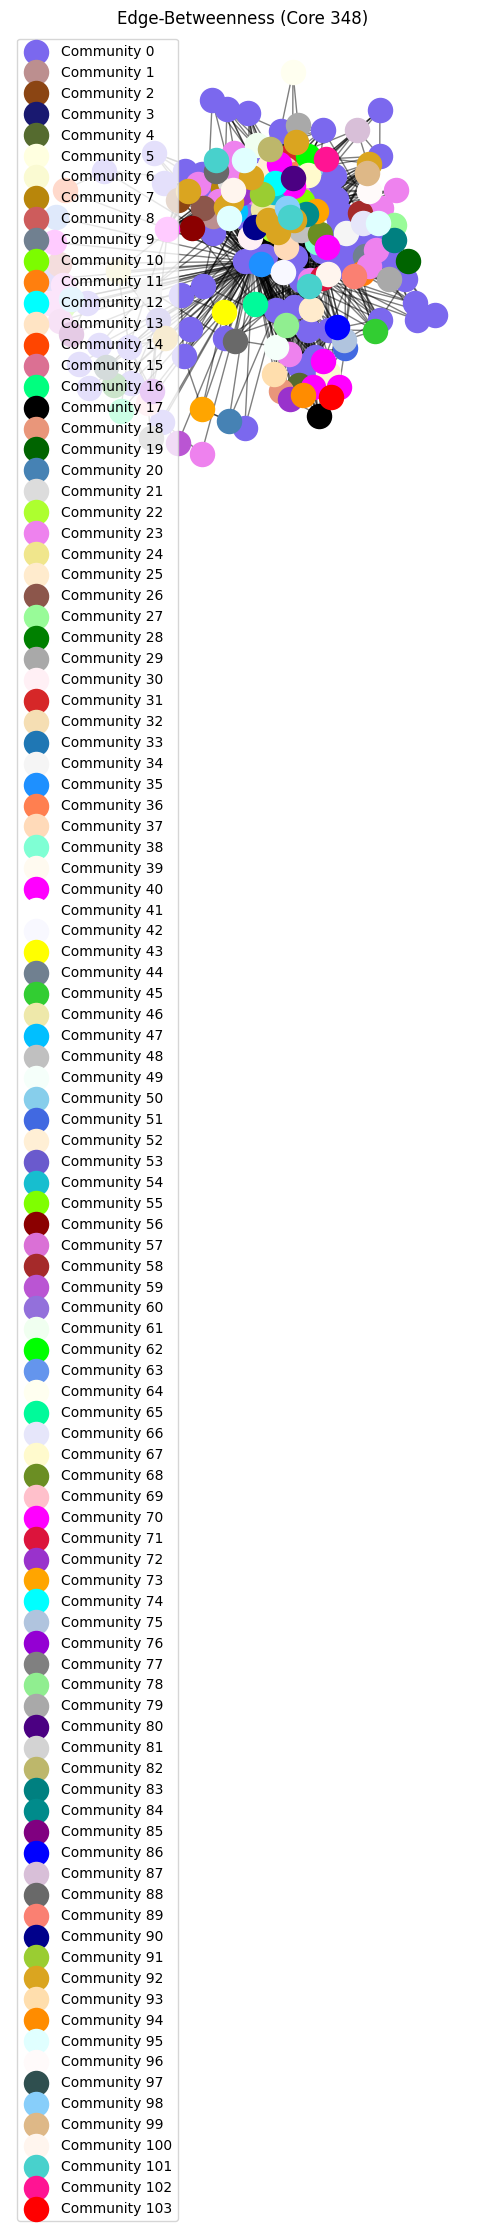

Edge-Betweenness modularity: 0.1335


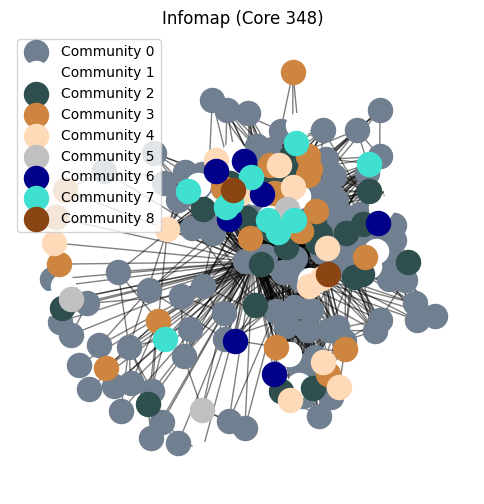

Infomap modularity: 0.2130
=== Core node 483 ===


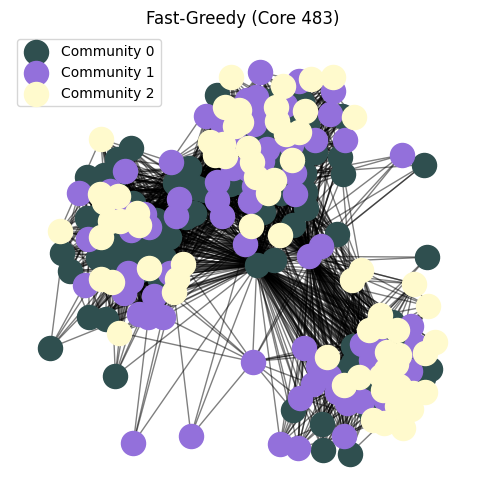

Fast-Greedy modularity: 0.5070


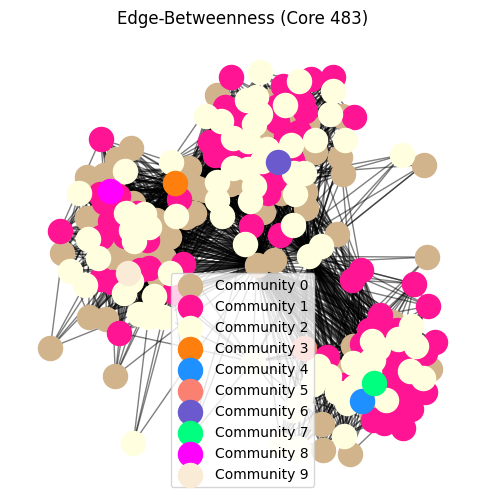

Edge-Betweenness modularity: 0.4891


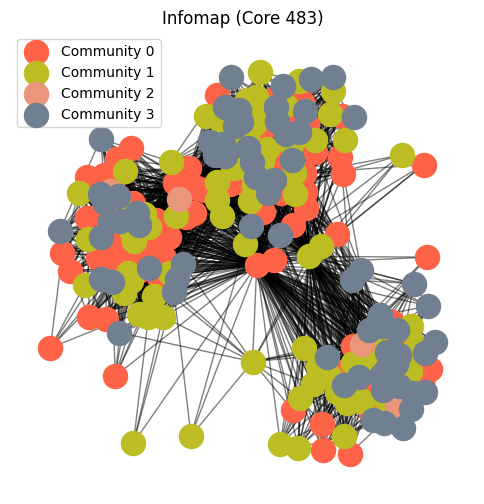

Infomap modularity: 0.5153
=== Core node 1086 ===


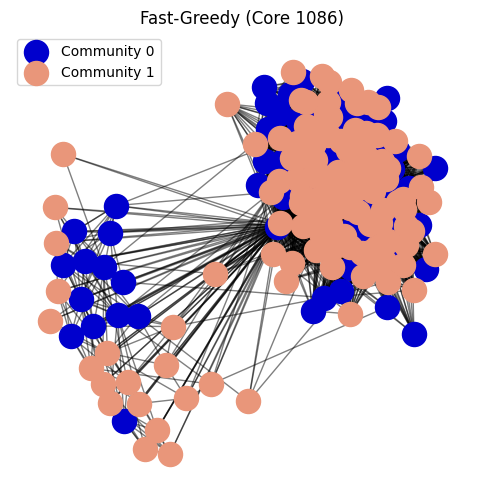

Fast-Greedy modularity: 0.1455


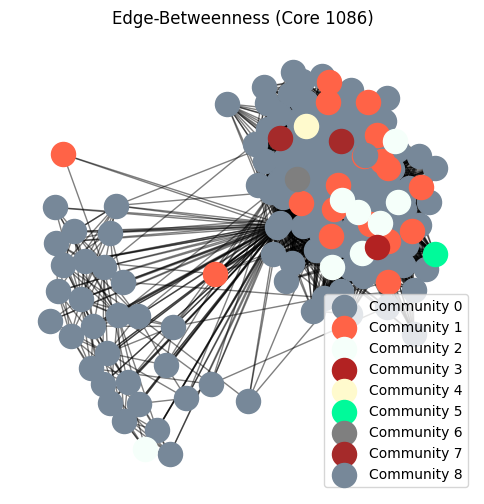

Edge-Betweenness modularity: 0.0276


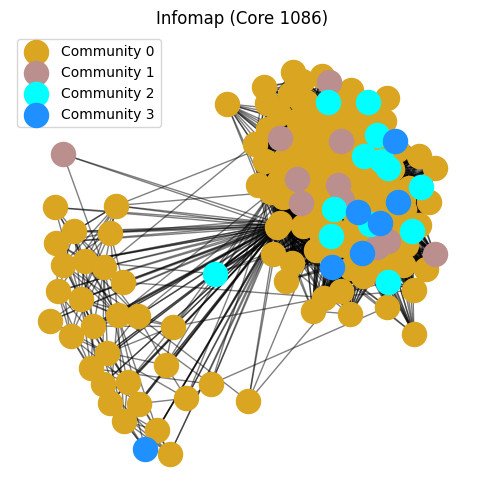

Infomap modularity: 0.0269


In [ ]:
for core in core_nodes:
    print(f"=== Core node {core} ===")
    G_personal = nx.ego_graph(G, core)

    mod_fg = fast_greedy(G_personal, core)
    print(f"Fast-Greedy modularity: {mod_fg:.4f}")

    mod_eb = edge_betweenness(G_personal, core)
    print(f"Edge-Betweenness modularity: {mod_eb:.4f}")

    mod_im = infomap(G_personal, core)
    print(f"Infomap modularity: {mod_im:.4f}")